# ❄️ Snow Classification

<center>
  <img src="images/15Advanced_LTC2026_KV_final.png" width="60%">
</center>

**Course website:**  
https://eo4society.esa.int/event/15th-advanced-training-course-on-land-remote-sensing-the-water-cycle/

**Instructors:** Carlo Marin and Valentina Premier, Eurac Research

---
## Overview

In this notebook, you will learn how to search, query, and access **Sentinel-2 Level-1C (L1C)** imagery for **snow mapping applications** using the **Copernicus Data Space Ecosystem (CDSE) STAC API**. You will then apply and compare different snow-mapping approaches to identify snow-covered pixels and distinguish them from snow-free areas.

The notebook demonstrates how to use the **[`stackstac`](https://stackstac.readthedocs.io/)** Python library to efficiently search, access, and load Sentinel-2 imagery directly from the **[Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/)** through its **[STAC API](https://documentation.dataspace.copernicus.eu/APIs/STAC.html)**.

## Learning Objectives

By the end of this notebook, you will be able to:

* Search for **Sentinel-2 Level-1C** scenes over an area of interest.
* Filter acquisitions based on spatial extent, acquisition date, and cloud cover.
* Load Sentinel-2 imagery directly into Python using **`stackstac`**.
* Explore the spectral characteristics of snow in the Sentinel-2 bands.
* Compute the **Normalized Difference Snow Index (NDSI)** and derive **Snow Cover Fraction (SCF)**.
* Apply and compare different snow-mapping approaches, including threshold-based methods and a **Support Vector Machine (SVM)** classifier.

---

#### Install and import
Uncomment the installation command only if an import fails, then restart the kernel.

In [1]:
# %pip install pystac-client stackstac odc-stac geopandas shapely rasterio dask matplotlib boto3 pyproj libgdal-jp2openjpeg rioxarray scikit-learn

In [22]:
import os
import xarray as xr
from getpass import getpass
import boto3
import json
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pystac_client import Client
import stackstac
from pyproj import CRS
from shapely.geometry import shape

from pathlib import Path
import sys

eotraining_dir = Path(
  "/home/jovyan/mystorage/SnowFLAKES_stac/eotraining"
)
sys.path.insert(0, str(eotraining_dir))

import aoi_map
import classification

####  Define an Area of Interest (AOI)

Draw a **polygon** around your study area using the interactive map below. The AOI will be saved as a **GeoJSON** file using the helper functions in `aoi_map.py` and will be used throughout this notebook to query and load **Sentinel-2** imagery from the **CDSE STAC API**.


In [13]:
m, aoi = aoi_map.create_aoi_map()
m

Map(center=[46.5, 11.3], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

The AOI will be saved as a GeoJSON file.

In [14]:
aoi_map.save_aoi_geojson(aoi, output_path="aoi.geojson")

PosixPath('aoi.geojson')

#### Configure CDSE S3 access

Create S3 credentials in the CDSE user area ([`S3 Credentials` → `Add Credential`](https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/auth?client_id=cdse-public&redirect_uri=https%3A%2F%2Feodata-s3keysmanager.dataspace.copernicus.eu%2F&state=aca7dc49-ebcb-4841-8201-60d922b3a004&response_mode=fragment&response_type=code&scope=openid&nonce=402de9bd-db77-4cfb-96d1-97744dfa08c1&code_challenge=H9DNWDy4lkwGf746C_0k-7LUfTH0YMHH1b_5qXIwnbM&code_challenge_method=S256). The secret key is shown only once. The following cell follows the official CDSE STAC convention: it uses `CDSE_S3_ACCESS_KEY` and `CDSE_S3_SECRET_KEY`, then maps them to the AWS variables used by GDAL.

In [15]:
# These environment variables are used by GDAL, Rasterio and stackstac
# to stream Sentinel-2 imagery directly from the cloud.
if not os.environ.get("CDSE_S3_ACCESS_KEY"):
    os.environ["CDSE_S3_ACCESS_KEY"] = getpass("CDSE S3 access key: " )
if not os.environ.get("CDSE_S3_SECRET_KEY"):
    os.environ["CDSE_S3_SECRET_KEY"] = getpass("CDSE S3 secret key: " )

os.environ["AWS_ACCESS_KEY_ID"] = os.environ["CDSE_S3_ACCESS_KEY"]
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ["CDSE_S3_SECRET_KEY"]
os.environ["AWS_REGION"] = "default"
os.environ["AWS_DEFAULT_REGION"] = "default"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".jp2,.tif,.tiff"
os.environ["VSI_CACHE"] = "TRUE"
os.environ["VSI_CACHE_SIZE"] = "67108864"


# Check that boto3 can see credentials without printing their values.
print("Credentials available:", bool(boto3.Session().get_credentials()))

Credentials available: True


#### Query the CDSE
With the **Area of Interest (AOI)** defined, we can query the **Copernicus Data Space Ecosystem (CDSE) STAC API** for available **Sentinel-2 Level-1C** acquisitions.


The **[SpatioTemporal Asset Catalog (STAC)](https://stacspec.org/en)** is an open specification for describing and discovering geospatial data. A STAC catalog organizes satellite products into **Collections** (e.g., Sentinel-2 L1C), while each acquisition is represented as a **STAC Item** containing spatial and temporal metadata together with links to the corresponding data assets (e.g., spectral bands).


The **CDSE STAC API** enables efficient searches based on an **area of interest (AOI)**, **acquisition date**, **cloud cover**, and other metadata. A major advantage of this approach is that data can be queried directly over the **AOI**, regardless of the underlying **Sentinel-2 tile grid**. This avoids manually identifying, downloading, and managing multiple **SAFE** products when the study area spans several tiles.


The AOI is loaded from the previously saved **GeoJSON** file and used as the search geometry through the `intersects` parameter. In this example, we search for scenes acquired during **January 2024** with **less than 20% cloud cover**. The query returns a collection of **STAC Items**, each representing a Sentinel-2 acquisition together with its associated metadata and links to the image assets.

In [16]:
# Load the AOI geometry
with open("aoi.geojson", "r") as f:
    aoi = json.load(f)

# Extract the geometry if the file is a GeoJSON Feature
geometry = aoi["geometry"] if aoi["type"] == "Feature" else aoi

# Open the CDSE STAC catalog
catalog = Client.open("https://stac.dataspace.copernicus.eu/v1")

# Search for Sentinel-2 L1C scenes
search = catalog.search(
    collections=["sentinel-2-l1c"],
    intersects=geometry,
    datetime="2024-01-01/2024-01-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(search.items())

print(f"Found {len(items)} scenes")

Found 6 scenes


#### Inspect the Search Results

The search returns a list of **STAC Items**, where each item corresponds to a single **Sentinel-2 acquisition**. We first inspect the basic metadata of each scene, including its **identifier**, **acquisition date**, and **estimated cloud cover**.

Next, we examine the first STAC Item to see which **assets** are available. Assets are the individual files associated with a scene, such as the spectral bands (e.g., **B02**, **B03**, **B04**, **B08**), quality masks, and metadata. These asset names will be used in the next step to select the bands that we want to load with **`stackstac`**.


In [17]:
for item in items:
    print(item.id, item.datetime, item.properties.get("eo:cloud_cover"))

first_item = items[0]
print("Available assets:", sorted(first_item.assets))

S2A_MSIL1C_20240128T101301_N0510_R022_T32TPS_20240128T105717 2024-01-28 10:13:01.024000+00:00 0.06
S2B_MSIL1C_20240126T102219_N0510_R065_T32TPS_20240126T111247 2024-01-26 10:22:19.024000+00:00 11.65
S2B_MSIL1C_20240116T102259_N0510_R065_T32TPS_20240116T111303 2024-01-16 10:22:59.024000+00:00 0.15
S2B_MSIL1C_20240113T101309_N0510_R022_T32TPS_20240113T110023 2024-01-13 10:13:09.024000+00:00 0.24
S2A_MSIL1C_20240111T102401_N0510_R065_T32TPS_20240111T122249 2024-01-11 10:24:01.024000+00:00 0.0
S2B_MSIL1C_20240103T101329_N0510_R022_T32TPS_20240103T110304 2024-01-03 10:13:29.024000+00:00 14.27
Available assets: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A', 'Product', 'TCI', 'datastrip_metadata', 'granule_metadata', 'inspire_metadata', 'product_metadata', 'safe_manifest', 'thumbnail']


#### Load the dataset with `stackstac`

The **`stackstac`** library reads the returned STAC Items and constructs a lazy-loaded **`xarray.DataArray`** backed by **Dask**. Rather than downloading complete products, only the requested data are accessed on demand, making it possible to efficiently work with large datasets while presenting them as a single multidimensional data cube with dimensions such as **time**, **band**, **x**, and **y**.

In [18]:
# Convert the GeoJSON geometry to a Shapely geometry
aoi_shape = shape(geometry)

# Create a GeoSeries in WGS84
aoi_gs = gpd.GeoSeries([aoi_shape], crs="EPSG:4326")

# Automatically estimate the best UTM CRS
target_crs = aoi_gs.estimate_utm_crs()
print(target_crs)

EPSG:32632


`stackstac` returns an `xarray.DataArray` backed by Dask. The cube remains lazy until `.compute()` is called. We load the first item.

In [19]:
gdal_env = stackstac.DEFAULT_GDAL_ENV.updated({
    "GDAL_NUM_THREADS": -1,
    "GDAL_HTTP_UNSAFESSL": "YES",
    "GDAL_HTTP_TCP_KEEPALIVE": "YES",
    "AWS_VIRTUAL_HOSTING": "FALSE",
    "AWS_HTTPS": "YES",
})


stack_cube = stackstac.stack(
    items=[first_item],
    assets=['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A'],
    bounds_latlon=aoi_shape.bounds,
    epsg = 32632,
    resolution=20,
    gdal_env=gdal_env,
)

print(stack_cube)

<xarray.DataArray 'stackstac-7bbeca694d0e72e2be03b3fd21c4268a' (time: 1,
                                                                band: 13,
                                                                y: 610, x: 508)> Size: 32MB
dask.array<fetch_raster_window, shape=(1, 13, 610, 508), dtype=float64, chunksize=(1, 1, 610, 508), chunktype=numpy.ndarray>
Coordinates: (12/56)
  * time                                   (time) datetime64[ns] 8B 2024-01-2...
    id                                     (time) <U60 240B 'S2A_MSIL1C_20240...
  * band                                   (band) <U3 156B 'B01' 'B02' ... 'B8A'
  * x                                      (x) float64 4kB 6.267e+05 ... 6.36...
  * y                                      (y) float64 5kB 5.164e+06 ... 5.15...
    constellation                          <U10 40B 'sentinel-2'
    ...                                     ...
    auth:refs                              <U2 8B 's3'
    file:size                             

In [20]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    stack_cube = stack_cube.compute()

[########################################] | 100% Completed | 6.87 ss


#### Explore bands
Now get familiar with the Sentinel-2 bands. Try to read and look inside each band.

What do you notice? What is the snow and other classes behaviour?
Which bands do you think are giving the most information about snow cover?
Use the table and the image for orientating through the bands.

<center>

**Sentinel-2 spectral bands**

![sentinel2 bands](images/cms_page_media1530image001.png__525.0x426.0_q85_subsampling-2.jpg)

</center>

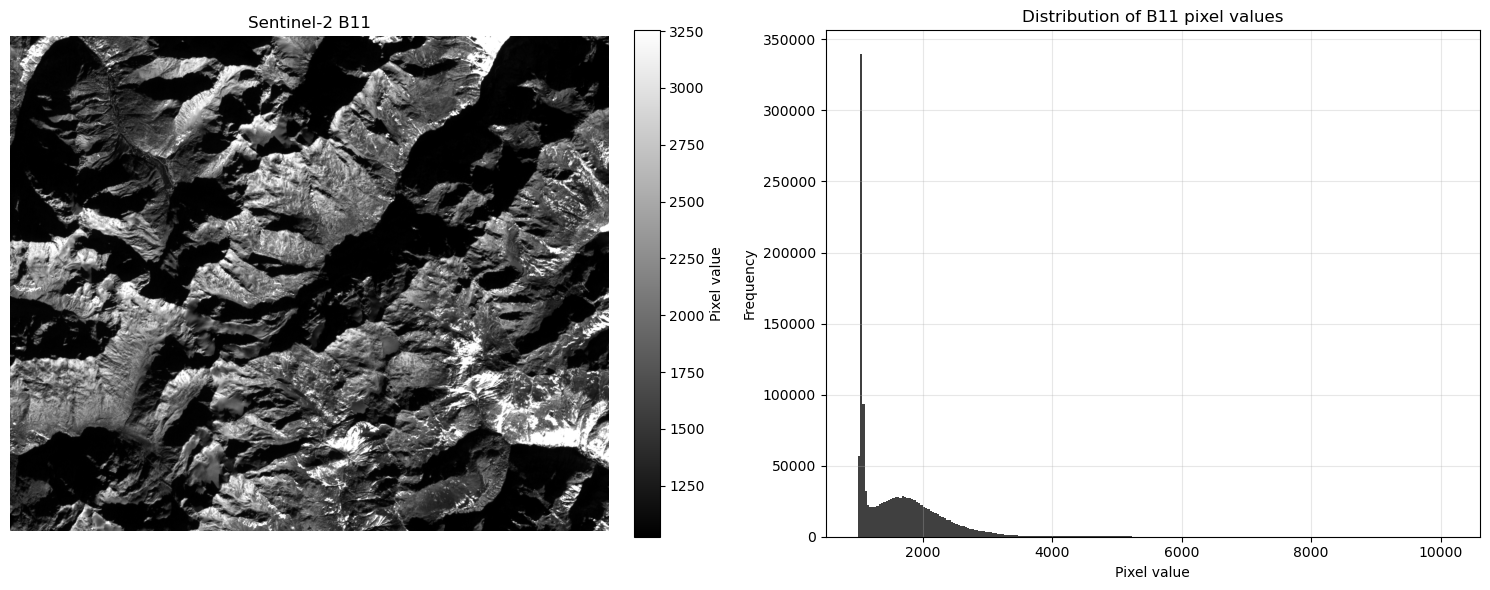

In [12]:
# Sentinel-2 band to explore
current_band_name = "B11"

# Select the band
selected_band = stack_cube.sel(band=current_band_name)

# If several acquisition dates are present, select the first one
if "time" in selected_band.dims:
    selected_band = selected_band.isel(time=0)


# Convert the xarray DataArray to a NumPy array
band = selected_band.values

# Keep only finite and valid reflectance values
valid_mask = np.isfinite(band) & (band > 0)
valid_values = band[valid_mask]

# Use percentiles to improve image contrast
vmin, vmax = np.percentile(valid_values, [2, 98])

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Display the band
img_plot = ax[0].imshow(
    band,
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

ax[0].set_title(f"Sentinel-2 {current_band_name}")
ax[0].axis("off")

cbar = plt.colorbar(
    img_plot,
    ax=ax[0],
    orientation="vertical",
    fraction=0.046,
    pad=0.04,
)
cbar.set_label("Pixel value")

# Plot only valid pixels in the histogram
ax[1].hist(
    valid_values,
    bins=256,
    color="black",
    alpha=0.75,
)

ax[1].set_title(f"Distribution of {current_band_name} pixel values")
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Frequency")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### False colour composites for data visualization
RGB composites help us to visually better interprete the scene.

Use the considerations you did before to combine different bands for creating a good combination for visualization.

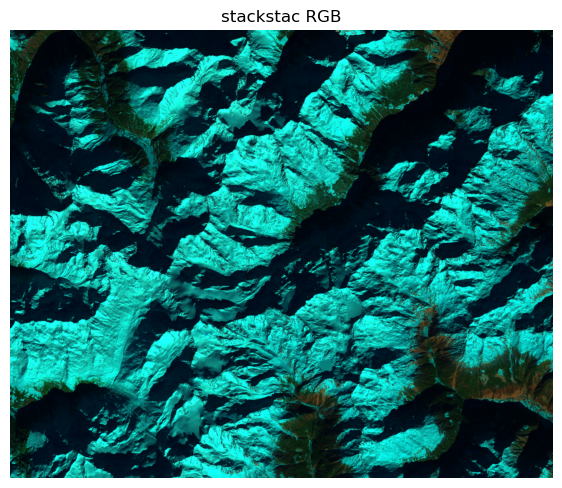

In [13]:
stack_rgb = stack_cube.sel(band=["B11", "B08", "B03"])
stack_values = np.asarray(np.squeeze(stack_rgb))
low, high = np.nanpercentile(stack_values, [2, 98])
stack_display = np.clip((stack_values - low) / (high - low), 0, 1)
plt.figure(figsize=(7, 7))
plt.imshow(np.moveaxis(stack_display, 0, -1))
plt.title("stackstac RGB")
plt.axis("off")
plt.show()

#### ❄️ NDSI (Normalized Difference Snow Index)

The **Normalized Difference Snow Index (NDSI)** is one of the most widely used spectral indices for detecting snow cover in optical satellite imagery. It exploits the fact that **snow is highly reflective in the visible (green) wavelengths but strongly absorbs radiation in the short-wave infrared (SWIR)**.

The NDSI is computed as:

$$
\mathrm{NDSI} = \frac{\rho_{\mathrm{Green}} - \rho_{\mathrm{SWIR}}}
{\rho_{\mathrm{Green}} + \rho_{\mathrm{SWIR}}}
$$

where:

- $\rho_{\mathrm{Green}}$ is the reflectance in the **Green** band (Sentinel-2 **B03**, 560 nm).
- $\rho_{\mathrm{SWIR}}$ is the reflectance in the **SWIR** band (Sentinel-2 **B11**, 1610 nm).

Typical NDSI values range from **-1 to 1**. Snow generally exhibits **high positive NDSI values**, while vegetation, water, and bare ground usually have lower values.

---

#### 🔍 Analysis of the Results

Inspect both the **NDSI image** and its **histogram**, then discuss the following questions:

1. Which areas are clearly identified as snow?
2. Which land cover types exhibit low or negative NDSI values?
3. Can you identify any regions where NDSI may incorrectly classify snow or non-snow?
4. What are the main limitations of using a single NDSI threshold for snow detection?
5. Which additional Sentinel-2 bands or information could help improve snow classification?

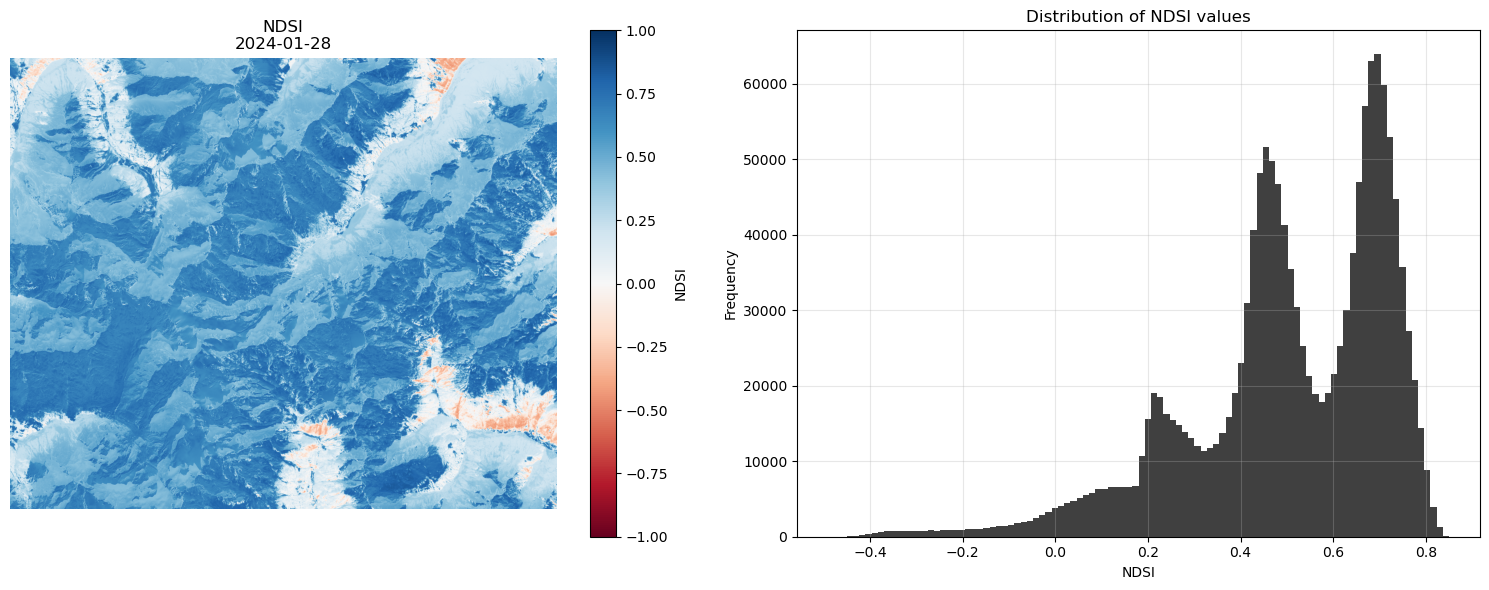

In [15]:
# Select one acquisition
green = stack_cube.sel(band="B03").isel(time=0)
swir = stack_cube.sel(band="B11").isel(time=0)

# Compute NDSI
ndsi = ((green - swir) / (green + swir)).compute()

# Acquisition date
acquisition_date = np.datetime_as_string(ndsi.time.values, unit="D")

# Valid values for the histogram
valid_values = ndsi.values[np.isfinite(ndsi.values)]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

im = ax[0].imshow(
    ndsi.values,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
)

ax[0].set_title(f"NDSI\n{acquisition_date}")
ax[0].axis("off")

plt.colorbar(im, ax=ax[0], label="NDSI")

ax[1].hist(valid_values, bins=100, color="black", alpha=0.75)
ax[1].set_title("Distribution of NDSI values")
ax[1].set_xlabel("NDSI")
ax[1].set_ylabel("Frequency")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Snow mapping applying a threshold on NDSI
Now considering the NDSI map and the relative histogram please select a proper threshold for distinguishing between snow covered and snow free areas.

Play a bit with the threshold and observe the result
Critically analyze what can be the main issues using NDSI thresold for snow mapping

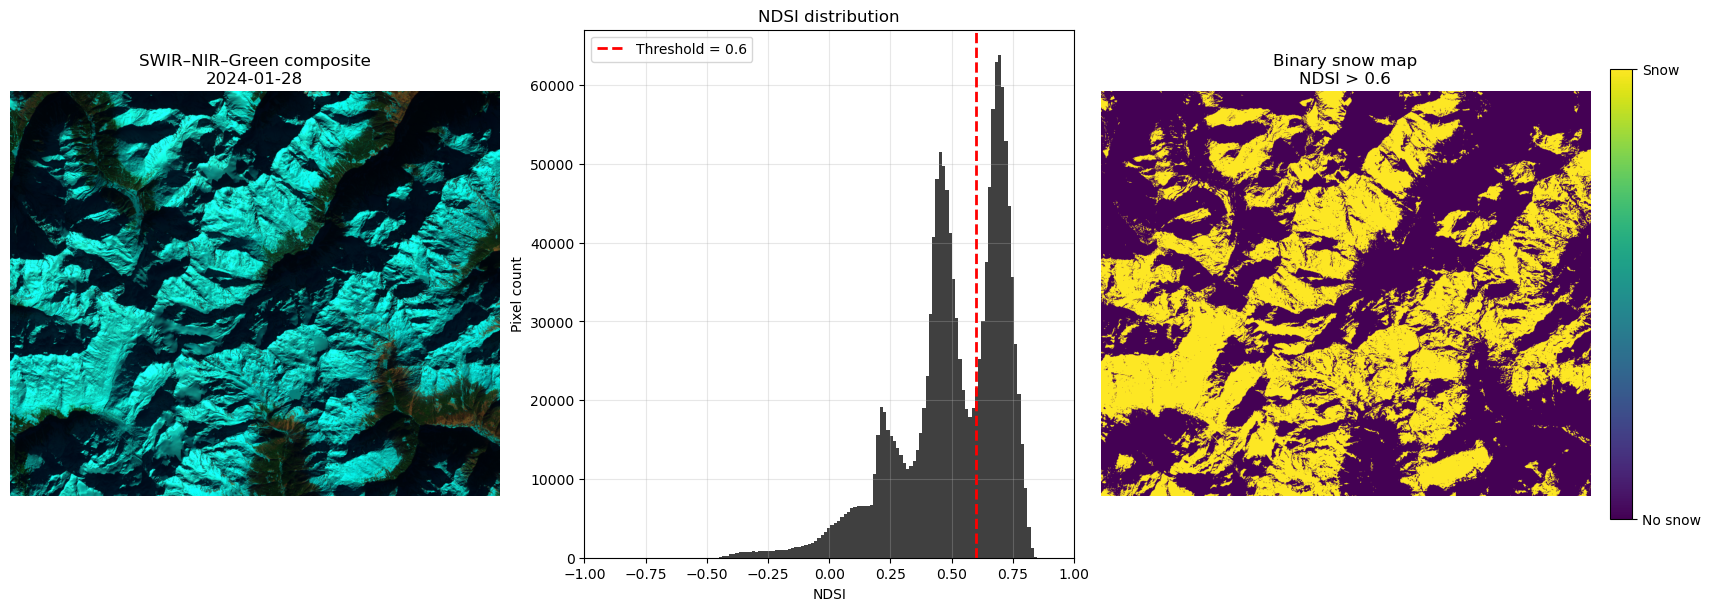

In [16]:
ndsi_threshold = 0.6

rgb_display = np.moveaxis(stack_display, 0, -1)

ndsi_array = ndsi.values
valid_ndsi = ndsi_array[np.isfinite(ndsi_array)]

# Binary snow map (100 = snow, 0 = no snow)
snow_map = np.where(ndsi_array > ndsi_threshold, 100, 0)

fig, ax = plt.subplots(1, 3, figsize=(17, 6), constrained_layout=True)

ax[0].imshow(rgb_display)
ax[0].set_title(f"SWIR–NIR–Green composite\n{acquisition_date}")
ax[0].axis("off")

ax[1].hist(valid_ndsi, bins=100, color="black", alpha=0.75)
ax[1].axvline(ndsi_threshold, color="red", ls="--", lw=2, label=f"Threshold = {ndsi_threshold}")
ax[1].set(title="NDSI distribution", xlabel="NDSI", ylabel="Pixel count", xlim=(-1, 1))
ax[1].grid(alpha=0.3)
ax[1].legend()

im = ax[2].imshow(snow_map, cmap="viridis", vmin=0, vmax=100)
ax[2].set_title(f"Binary snow map\nNDSI > {ndsi_threshold}")
ax[2].axis("off")

cbar = fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 100])
cbar.set_ticklabels(["No snow", "Snow"])

plt.show()

#### ❄️ Snow Cover Fraction Mapping with a Sigmoid Function

Now we estimate the **Snow Cover Fraction (SCF)** of a Sentinel-2 scene using a sigmoid relationship derived from the **Normalized Difference Snow Index (NDSI)**.

SCF represents the percentage of each pixel that is covered by snow. Unlike a binary snow map, which classifies each pixel only as *snow* or *no snow*, SCF provides a continuous estimate ranging from:

* **0%** — no snow cover
* **100%** — fully snow-covered pixel

This provides a more detailed representation of partially snow-covered areas.


The Snow Cover Fraction is estimated from NDSI using the following sigmoid relationship:

$$
\mathrm{SCF} = \frac{1}{2}\mathrm{tanh}(2.65 \mathrm{NDSI}-1.42) +0.5
$$

---

#### 📚 Reference

[2] Gascoin, S., Barrou Dumont, Z., Deschamps-Berger, C., Marti, F., Salgues, G., López-Moreno, J. I., Revuelto, J., Michon, T., Schattan, P., and Hagolle, O. (2020). *Estimating Fractional Snow Cover in Open Terrain from Sentinel-2 Using the Normalized Difference Snow Index*. Remote Sensing, **12**, 2904. https://doi.org/10.3390/rs12182904


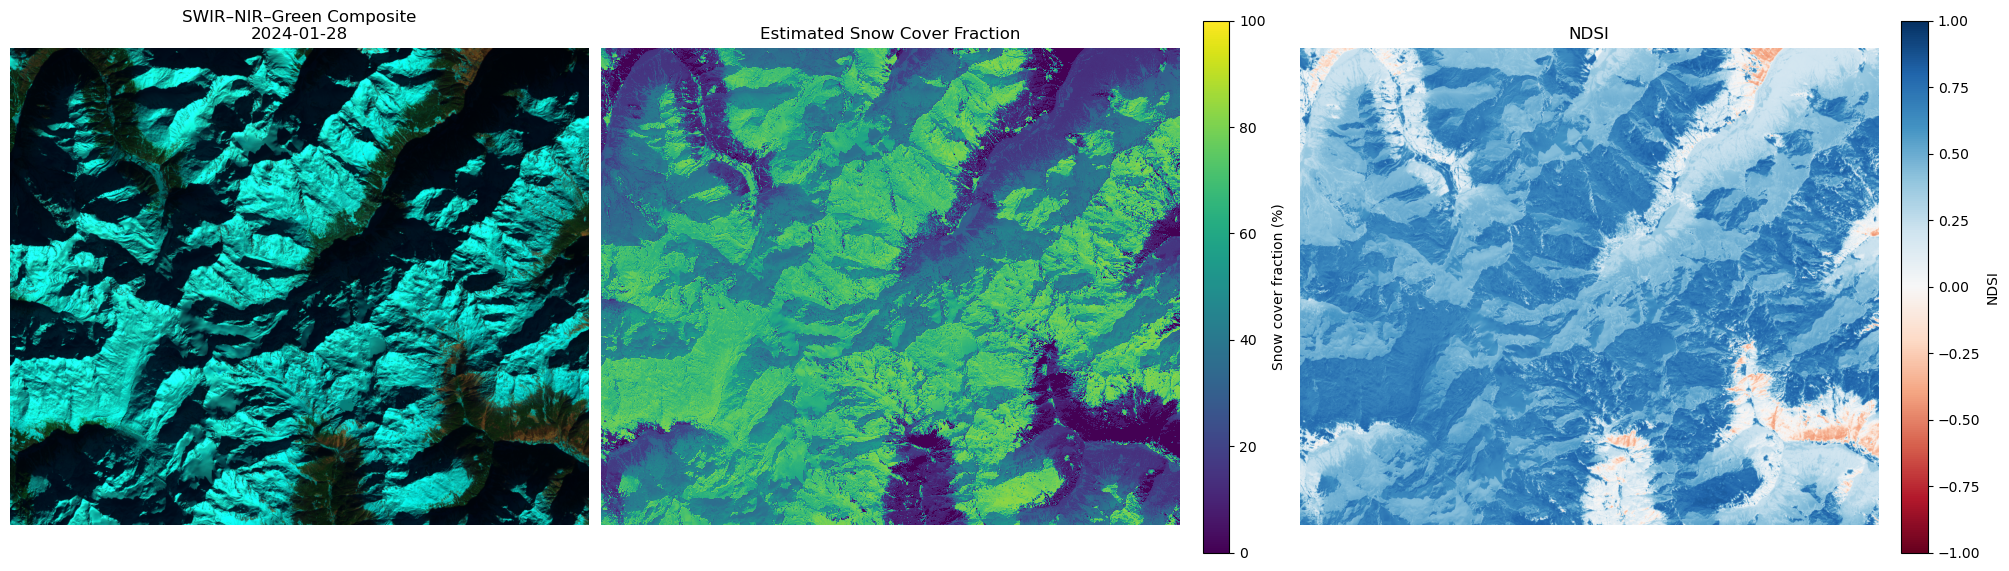

In [17]:
# Multiplicative and additive factors
c = 2.65
d = 1.42

scf_sigmoid = (
    0.5 * np.tanh(c * ndsi - d) + 0.5
) * 100.0

# Restrict SCF to the physical range 0–100%
scf_sigmoid = scf_sigmoid.clip(
    min=0,
    max=100,
)

# Set SCF to zero for non-positive NDSI values,
# while preserving invalid pixels as NaN
scf_sigmoid = xr.where(
    ndsi <= 0,
    0.0,
    scf_sigmoid,
)

scf_sigmoid = scf_sigmoid.where(
    np.isfinite(ndsi)
)

# Convert to NumPy for validation and plotting
scf_sigmoid_array = scf_sigmoid.values


# Plot the results
rgb_display = np.moveaxis(stack_display, 0, -1)
fig, ax = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# False-colour composite
ax[0].imshow(rgb_display)
ax[0].set_title(
    f"SWIR–NIR–Green Composite\n{acquisition_date}"
)
ax[0].axis("off")

# Estimated SCF
estimated_plot = ax[1].imshow(
    scf_sigmoid_array,
    cmap="viridis",
    vmin=0,
    vmax=100,
    interpolation="nearest",
)

ax[1].set_title("Estimated Snow Cover Fraction")
ax[1].axis("off")

estimated_cbar = plt.colorbar(
    estimated_plot,
    ax=ax[1],
    fraction=0.046,
    pad=0.04,
)

estimated_cbar.set_label("Snow cover fraction (%)")

ndsi_plot = ax[2].imshow(ndsi.values, cmap="RdBu", vmin=-1, vmax=1)
ax[2].set_title("NDSI")
ax[2].axis("off")
fig.colorbar(ndsi_plot, ax=ax[2], fraction=0.046, pad=0.04, label="NDSI")

plt.show()

#### Endmember Selection

In this section, we will prepare the training dataset needed to train a **Support Vector Machine (SVM)** classifier.

Support Vector Machines are supervised learning algorithms used for both classification and regression. In classification tasks, the objective of an SVM is to identify the optimal decision boundary, or **hyperplane**, that separates the different classes in the feature space.

Before training the classifier, we first need to collect representative training samples, also referred to here as **endmembers**. These samples should correspond to pixels that clearly represent the target classes:

* **Pure snow**
* **Pure snow-free terrain**

Careful selection of these samples is essential, because the quality and representativeness of the training data strongly influence the performance of the final classification.


In [32]:
training_map, collected = aoi_map.create_training_map(rgb_display, stack_cube)

NameError: name 'rgb_display' is not defined

Now we apply the SVM using the interactive samples collected above. **Support Vector Machines (SVMs)** are supervised learning models used for both classification and regression. The goal of an SVM is to find a hyperplane in an N-dimensional space that best separates the data points into distinct classes.

### Linearly separable classes

![image.png](images/svm.png) 

$$
f(x) =
\begin{cases}
  \text{100 if DF} \geq 1\\
  \text{50DF + 50 if -1 < DF < 1} \\
  \text{0 if DF} \leq -1
\end{cases}
$$

With: $$DF=\sum_{i=1}^ny_i\alpha_i\overline{x}_i\cdot\overline{x}_u+b$$

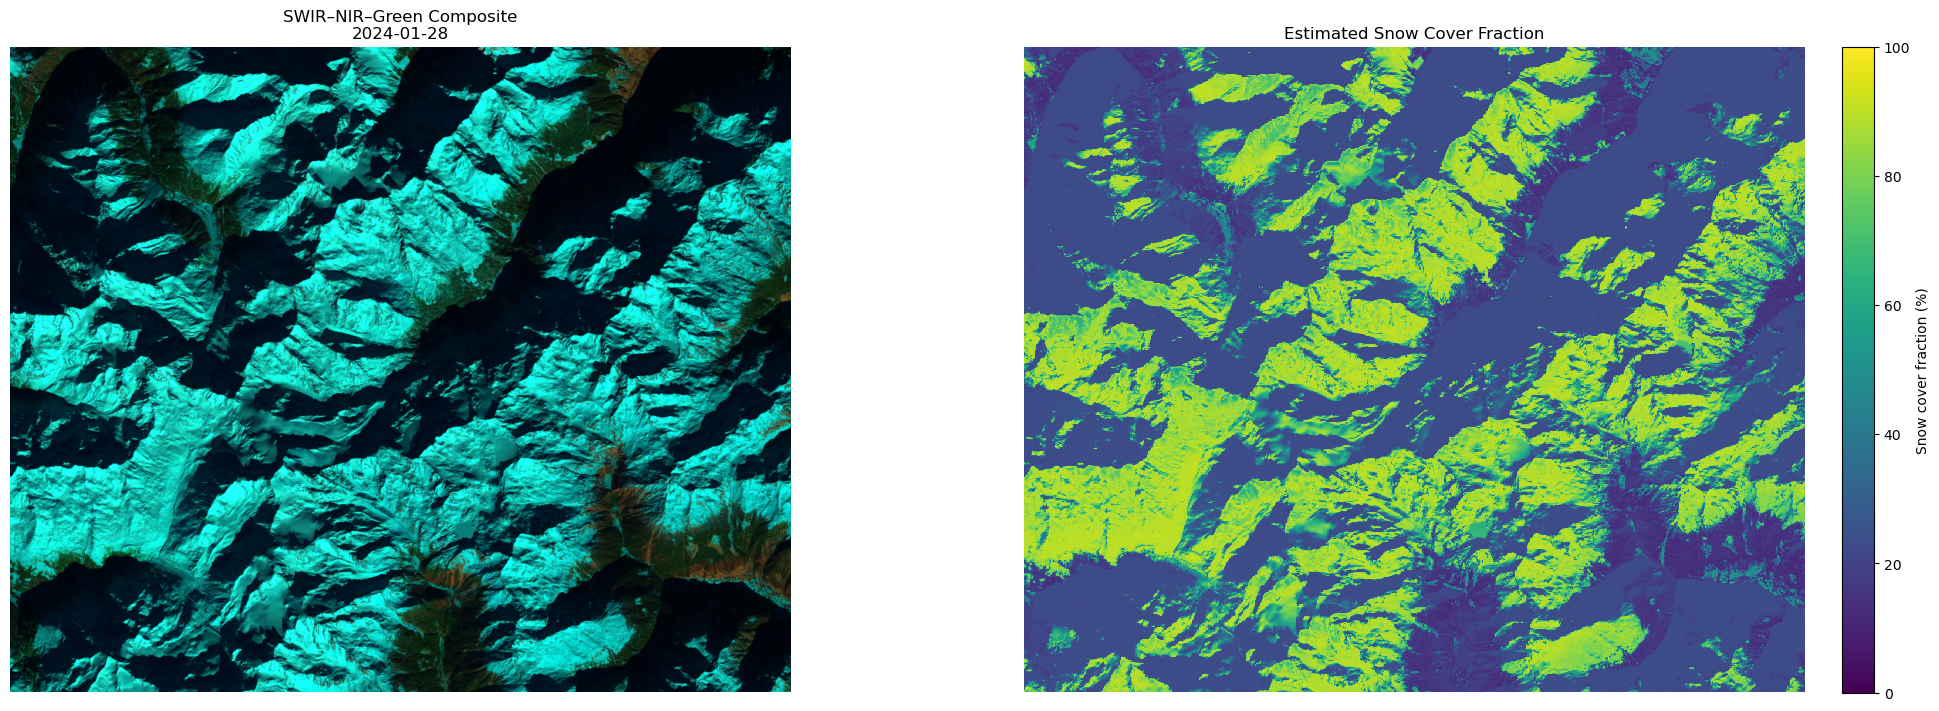

In [21]:
interactive_samples = gpd.GeoDataFrame(collected, crs="EPSG:4326")
reflectance_scf, reflectance_model = classification.SVM(
    stack_cube,
    interactive_samples,
)


# Plot the results
rgb_display = np.moveaxis(stack_display, 0, -1)
fig, ax = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)

# False-colour composite
ax[0].imshow(rgb_display)
ax[0].set_title(
    f"SWIR–NIR–Green Composite\n{acquisition_date}"
)
ax[0].axis("off")

# Estimated SCF
estimated_plot = ax[1].imshow(
    reflectance_scf,
    cmap="viridis",
    vmin=0,
    vmax=100,
    interpolation="nearest",
)

ax[1].set_title("Estimated Snow Cover Fraction")
ax[1].axis("off")

estimated_cbar = plt.colorbar(
    estimated_plot,
    ax=ax[1],
    fraction=0.046,
    pad=0.04,
)

estimated_cbar.set_label("Snow cover fraction (%)")

Now, try experimenting with the training collection and learn through **trial and error**.

What do you observe? Do you notice any challenges or limitations?

### Want to learn more?

Of course, when we need to classify a large number of images, manually collecting training samples becomes impractical. For this reason, we have worked extensively on an automatic classification algorithm called **SnowFLAKES**.

If you would like to explore a more automated approach, have a look at our GitHub repositories and the complete **SnowFLAKES pipeline** for classifying large collections of images:

* **Original version:** [https://github.com/bare92/SnowFLAKES](https://github.com/bare92/SnowFLAKES)
* **Current version:** [https://github.com/vpremier/SnowFLAKES_stac](https://github.com/vpremier/SnowFLAKES_stac)

### Acknowledgements

This work was developed within the **SNOWCOP project**. Learn more about the project at [snowcop.eu](https://snowcop.eu/).

The SNOWCOP project has received funding from the European Union's Horizon Europe Research and Innovation Actions programme under Grant Agreement No. **101180133**.